In [2]:
import pandas as pd
import matplotlib.pyplot as plt

day_1_prices = pd.read_csv("../data/prices_round_0_day_-1.csv", sep=";")
day_1_trades = pd.read_csv("../data/trades_round_0_day_-1.csv", sep=";")
day_2_prices = pd.read_csv("../data/prices_round_0_day_-2.csv", sep=";")
day_2_trades = pd.read_csv("../data/trades_round_0_day_-1.csv", sep=";")

day_1_tom_prices = day_1_prices[day_1_prices["product"] == "TOMATOES"].copy()
day_2_tom_prices = day_2_prices[day_2_prices["product"] == "TOMATOES"].copy()
day_1_eme_prices = day_1_prices[day_1_prices["product"] == "EMERALDS"].copy()
day_2_eme_prices = day_2_prices[day_2_prices["product"] == "EMERALDS"].copy()

tom_prices = pd.concat([day_2_tom_prices, day_1_tom_prices])
eme_prices = pd.concat([day_2_eme_prices, day_1_eme_prices])

tom_prices["global_time"] = tom_prices["day"] * 1_000_000 + tom_prices["timestamp"]
eme_prices["global_time"] = eme_prices["day"] * 1_000_000 + eme_prices["timestamp"]

tom_prices = tom_prices.sort_values(["global_time"]).reset_index(drop=True)
eme_prices = eme_prices.sort_values(["global_time"]).reset_index(drop=True)

In [3]:
tom_prices.head()

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss,global_time
0,-2,0,TOMATOES,4993,7,4992,17,NaN,NaN,5007,7,5008,17,NaN,NaN,5000.0,0.0,-2000000
1,-2,100,TOMATOES,4998,5,4993,7,4992.0,16.0,5007,7,5008,16,NaN,NaN,5002.5,0.0,-1999900
2,-2,200,TOMATOES,4994,6,4993,20,NaN,NaN,5008,6,5009,20,NaN,NaN,5001.0,0.0,-1999800
3,-2,300,TOMATOES,4995,5,4993,21,NaN,NaN,5008,5,5009,21,NaN,NaN,5001.5,0.0,-1999700
4,-2,400,TOMATOES,4995,8,4993,20,NaN,NaN,5008,8,5009,20,NaN,NaN,5001.5,0.0,-1999600


In [49]:
tom_prices["bid_volume"] = tom_prices["bid_volume_1"] + tom_prices["bid_volume_2"] + tom_prices["bid_volume_3"]
tom_prices["ask_volume"] = tom_prices["ask_volume_1"] + tom_prices["ask_volume_2"] + tom_prices["ask_volume_3"]

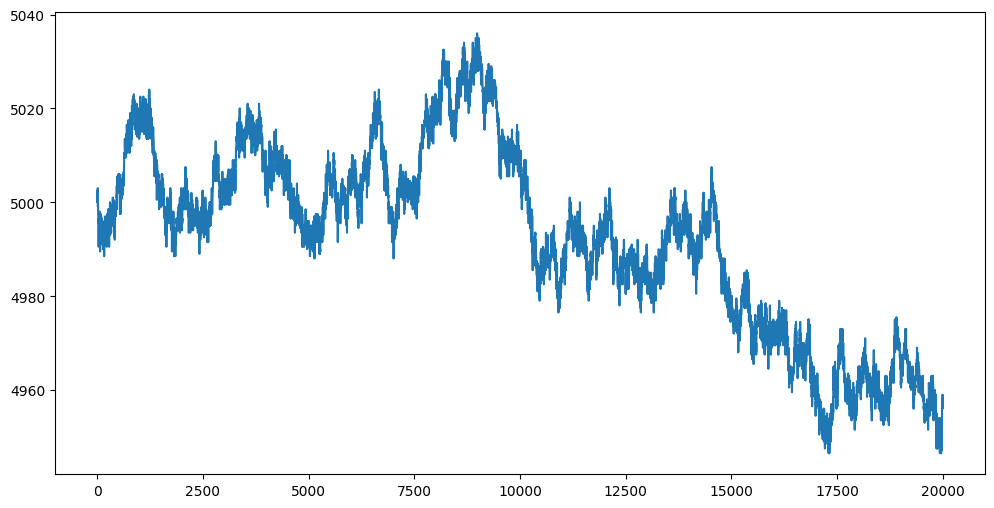

In [54]:
plt.figure(figsize=(12, 6))
plt.plot(tom_prices.index, tom_prices["mid_price"])

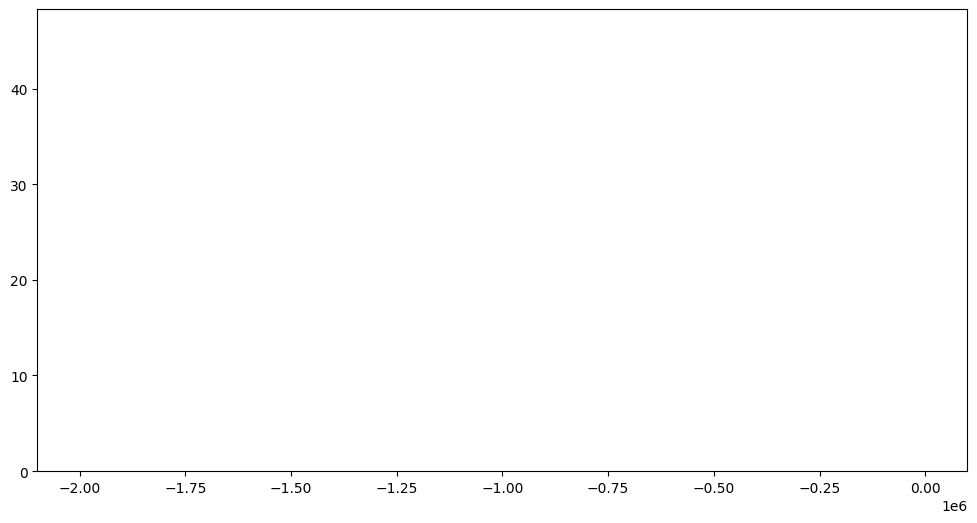

In [58]:
plt.figure(figsize=(12, 6))
plt.bar(tom_prices["global_time"], tom_prices["bid_volume"])
plt.show()

In [ ]:
plt.hist()

In [14]:
tom_prices["returns"] = tom_prices["mid_price"].diff()

print(tom_prices["returns"].describe())

count    19999.000000
mean        -0.002150
std          1.341035
min         -8.500000
25%         -0.500000
50%          0.000000
75%          0.500000
max          7.500000
Name: returns, dtype: float64


<Axes: >

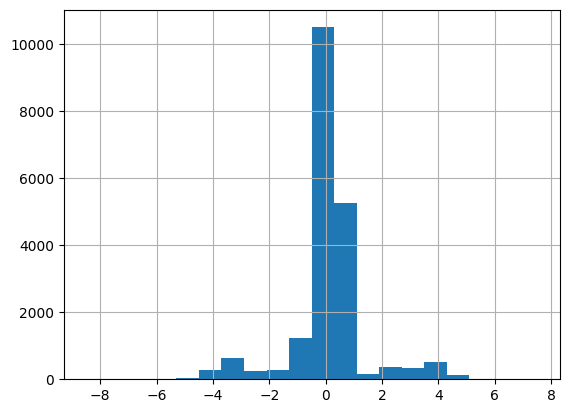

In [17]:
tom_prices["returns"].hist(bins=20)

In [18]:
tom_prices["up_move"] = tom_prices["returns"] > 0
tom_prices["down_move"] = tom_prices["returns"] < 0

print("Up after up:", (tom_prices["up_move"] & tom_prices["up_move"].shift(1)).mean())
print("Down after down:", (tom_prices["down_move"] & tom_prices["down_move"].shift(1)).mean())

Up after up: 0.0928
Down after down: 0.0959


In [ ]:
tom_prices["mean"] = tom_prices["mid_price"].rolling(20).mean()
tom_prices["dev"] = tom_prices["mid_price"] - tom_prices["mean"]

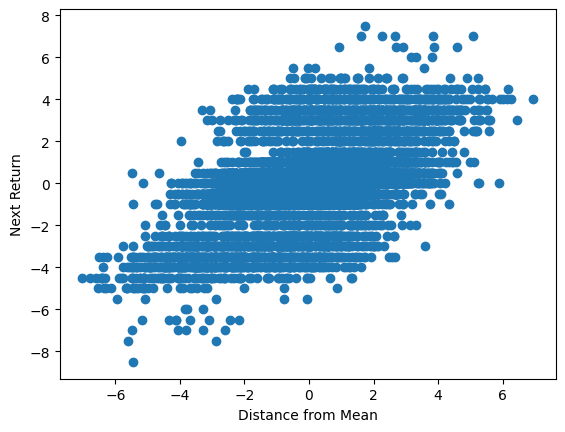

In [ ]:
plt.scatter(tom_prices["dev"], tom_prices["returns"])
plt.xlabel("Deviation from Mean")
plt.ylabel("Next Return")
plt.show()

In [25]:
tom_prices["spread"] = tom_prices["ask_price_1"] - tom_prices["bid_price_1"]

tom_prices["spread"].describe()

count    20000.000000
mean        13.020250
std          1.754592
min          5.000000
25%         13.000000
50%         13.000000
75%         14.000000
max         14.000000
Name: spread, dtype: float64

In [36]:
tom_prices["vol"] = tom_prices["returns"].rolling(20).std()

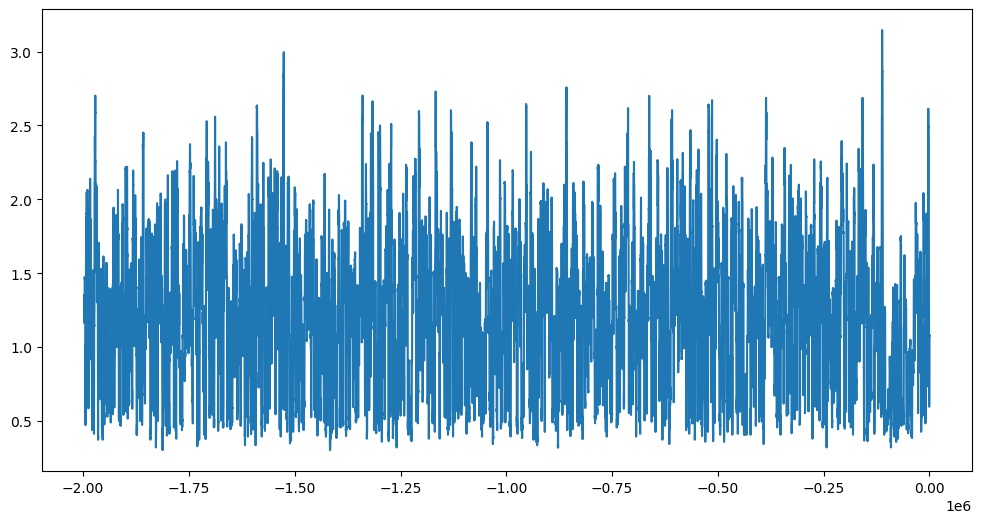

In [37]:
plt.figure(figsize=(12, 6))
plt.plot(tom_prices["global_time"], tom_prices["vol"])

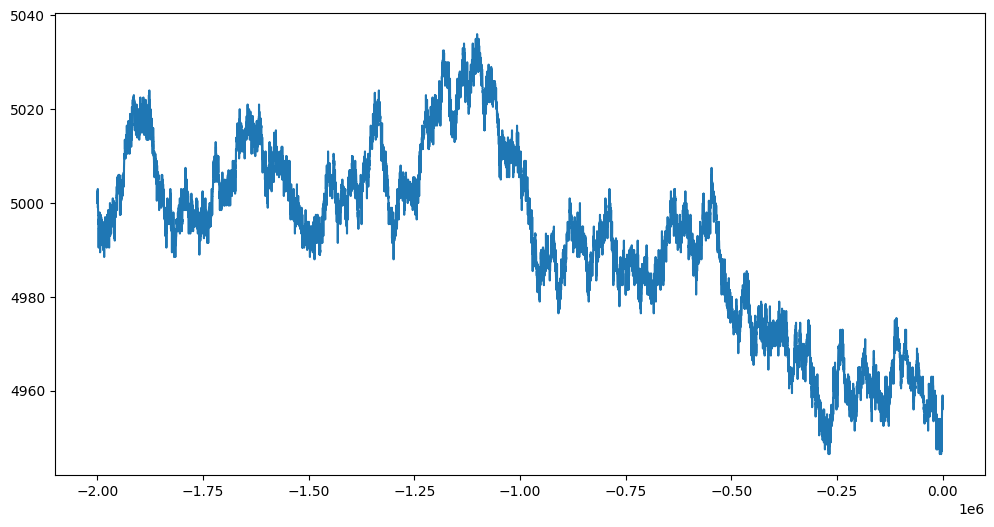

In [30]:
plt.figure(figsize=(12, 6))
plt.plot(tom_prices["global_time"], tom_prices["mid_price"])

In [38]:
import numpy as np

def evaluate_window(prices, window, horizon=5):
    prices = np.array(prices)

    rolling_mean = pd.Series(prices).rolling(window).mean().values
    signal = prices - rolling_mean

    future_returns = np.roll(prices, -horizon) - prices

    # remove invalid rows
    mask = ~np.isnan(signal)
    mask &= ~np.isnan(future_returns)

    signal = signal[mask]
    future_returns = future_returns[mask]

    # correlation between signal and future return
    corr = np.corrcoef(signal, future_returns)[0, 1]

    # mean PnL if we traded this signal
    pnl = -np.sign(signal) * future_returns
    avg_pnl = np.mean(pnl)

    return corr, avg_pnl

In [40]:
results = []

for w in range(2, 50):
    corr, pnl = evaluate_window(tom_prices["mid_price"], window=w, horizon=5)
    results.append((w, corr, pnl))

results_df = pd.DataFrame(results, columns=["window", "correlation", "avg_pnl"])

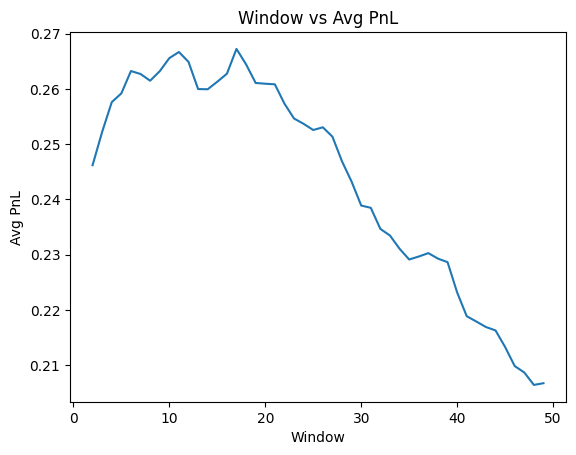

In [45]:
plt.plot(results_df["window"], results_df["avg_pnl"])
plt.title("Window vs Avg PnL")
plt.xlabel("Window")
plt.ylabel("Avg PnL")
plt.show()

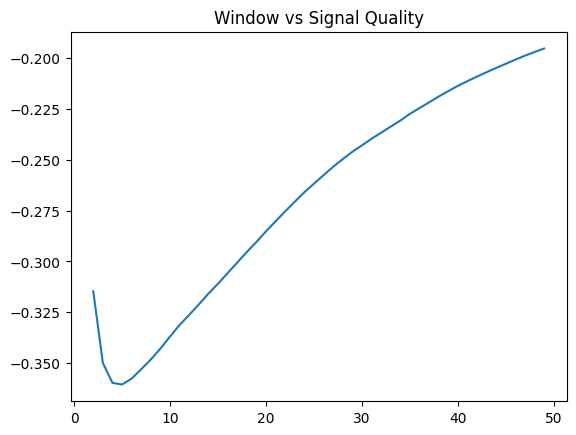

In [44]:
plt.plot(results_df["window"], results_df["correlation"])
plt.title("Window vs Signal Quality")
plt.show()

In [46]:
def evaluate_with_threshold(prices, window, threshold=2, horizon=5):
    prices = np.array(prices)
    rolling_mean = pd.Series(prices).rolling(window).mean().values

    signal = prices - rolling_mean
    future_returns = np.roll(prices, -horizon) - prices

    mask = ~np.isnan(signal)
    mask &= ~np.isnan(future_returns)

    signal = signal[mask]
    future_returns = future_returns[mask]

    trades = np.abs(signal) > threshold

    if trades.sum() == 0:
        return 0

    pnl = -np.sign(signal[trades]) * future_returns[trades]
    return np.mean(pnl)

In [47]:
evaluate_with_threshold(tom_prices["mid_price"], 8)

np.float64(2.830007127583749)